In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [21]:
df = pd.read_excel("../data/OnlineRetail.xlsx")

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [19]:
df.shape

(541909, 8)

In [20]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [27]:
df = df.dropna(subset=['CustomerID'])

In [28]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [29]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [30]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [31]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [32]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [33]:
df[['Quantity','UnitPrice','TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [34]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [35]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 397884
Columns: 9


In [36]:
df.describe()

,Quantity,UnitPrice,CustomerID,TotalAmount
count,397884.000000,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453,22.397000
std,179.331775,22.097877,1713.141560,309.071041
min,1.000000,0.001000,12346.000000,0.001000
25%,2.000000,1.250000,13969.000000,4.680000
50%,6.000000,1.950000,15159.000000,11.800000
75%,12.000000,3.750000,16795.000000,19.800000
max,80995.000000,8142.750000,18287.000000,168469.600000


In [37]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')

In [38]:
df[['CustomerID','InvoiceDate','TotalAmount']].head()

,CustomerID,InvoiceDate,TotalAmount
0,17850.0,2010-12-01 08:26:00,15.30
1,17850.0,2010-12-01 08:26:00,20.34
2,17850.0,2010-12-01 08:26:00,22.00
3,17850.0,2010-12-01 08:26:00,20.34
4,17850.0,2010-12-01 08:26:00,20.34


In [39]:
df['CustomerID'].nunique()

4338

### RFM


In [40]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [41]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [42]:
rfm.columns = ['Recency','Frequency','Monetary']

In [43]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [44]:
rfm.shape

(4338, 3)

In [45]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [46]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

### RFM EDA


In [47]:
rfm.shape[0]

4338

In [48]:
rfm['Recency'].mean()

92.53642231443061

In [49]:
rfm['Frequency'].mean()

4.272014753342554

In [50]:
rfm['Monetary'].mean()

2054.2664601198708

In [51]:
rfm['Monetary'].idxmax()

14646.0

In [52]:
rfm['Monetary'].max()

280206.02

In [53]:
rfm['Frequency'].idxmax()

12748.0

In [54]:
rfm['Frequency'].max()

209

In [55]:
rfm['Recency'].idxmin()

12423.0

In [56]:
rfm['Recency'].idxmax()

12791.0

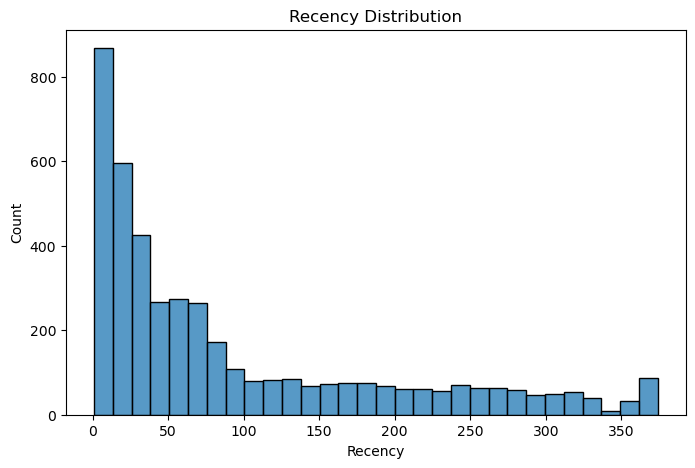

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'], bins=30)
plt.title("Recency Distribution")
plt.show()

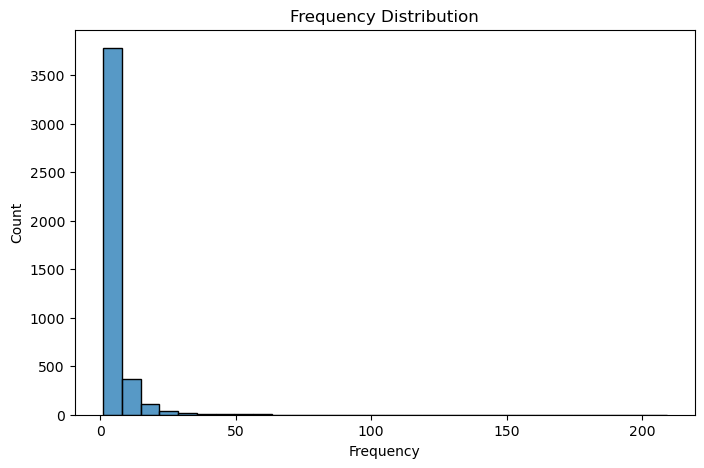

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Frequency'], bins=30)
plt.title("Frequency Distribution")
plt.show()

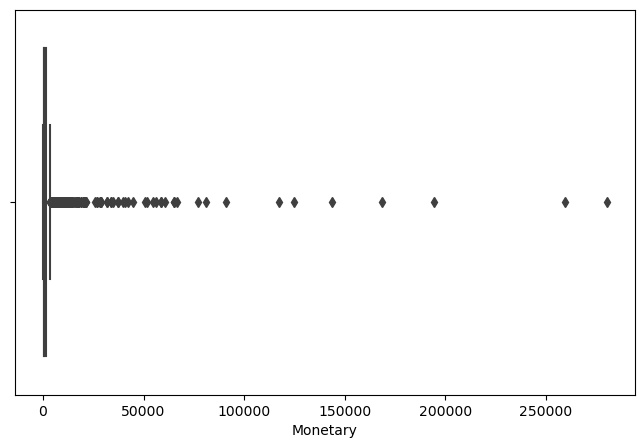

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(x=rfm['Monetary'])
plt.show()

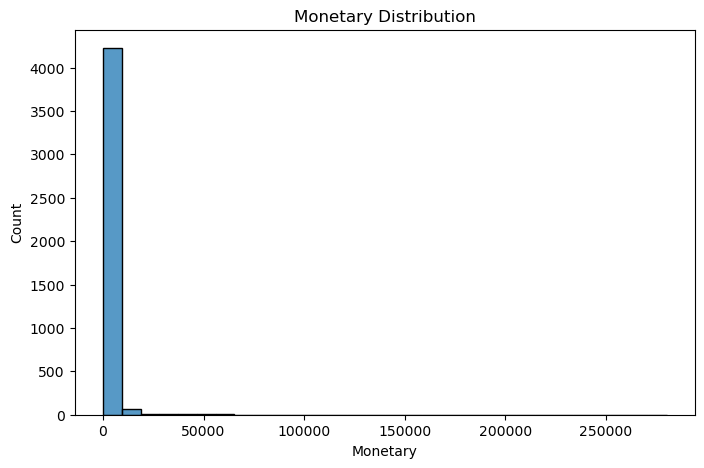

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'], bins=30)
plt.title("Monetary Distribution")
plt.show()

In [61]:
rfm_log = rfm.copy()

rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])

In [62]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.593627
std,1.340261,0.683104,1.257578
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.731446
50%,3.951244,1.098612,6.515431
75%,4.962845,1.791759,7.416222
max,5.926926,5.347108,12.543284


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled.shape

(4338, 3)

In [65]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

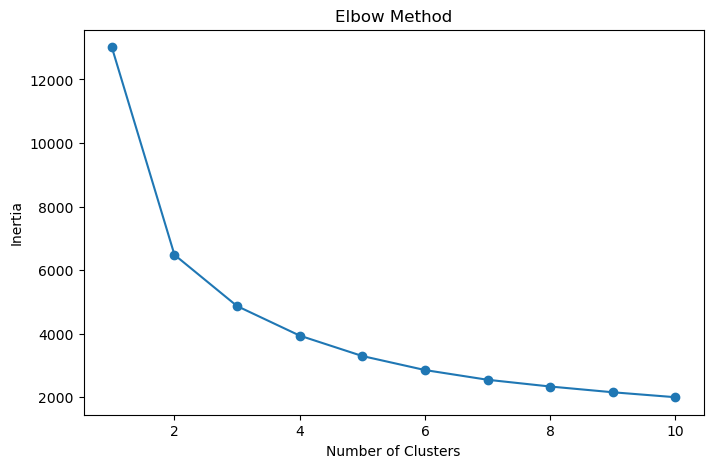

In [66]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [67]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(f"k={k}, score={score:.4f}")

k=2, score=0.4329
k=3, score=0.3365
k=4, score=0.3371
k=5, score=0.3161
k=6, score=0.3133
k=7, score=0.3100
k=8, score=0.3008
k=9, score=0.2817
k=10, score=0.2787


In [68]:
rfm_scaled.shape

(4338, 3)

In [69]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [70]:
rfm['Cluster'].value_counts()

3    1612
2    1173
0     837
1     716
Name: Cluster, dtype: int64

In [71]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,18.124253,2.148148,551.819534
1,12.131285,13.713687,8074.266872
2,71.084399,4.083546,1802.829005
3,182.496898,1.318238,343.450032


In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PCA1','PCA2']
)

pca_df['Cluster'] = rfm['Cluster']

In [74]:
pca_df.head()

,PCA1,PCA2,Cluster
0,0.872658,2.686758,NaN
1,2.550260,-0.804427,NaN
2,0.475142,0.746121,NaN
3,0.145832,-0.460480,NaN
4,-1.688990,0.676555,NaN


In [75]:
pca_df.columns

Index(['PCA1', 'PCA2', 'Cluster'], dtype='object')

In [77]:
pca_df = pd.DataFrame(
    pca_data,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = rfm['Cluster'].values

pca_df.head()

,PCA1,PCA2,Cluster
0,0.872658,2.686758,2
1,2.550260,-0.804427,1
2,0.475142,0.746121,2
3,0.145832,-0.460480,0
4,-1.688990,0.676555,3


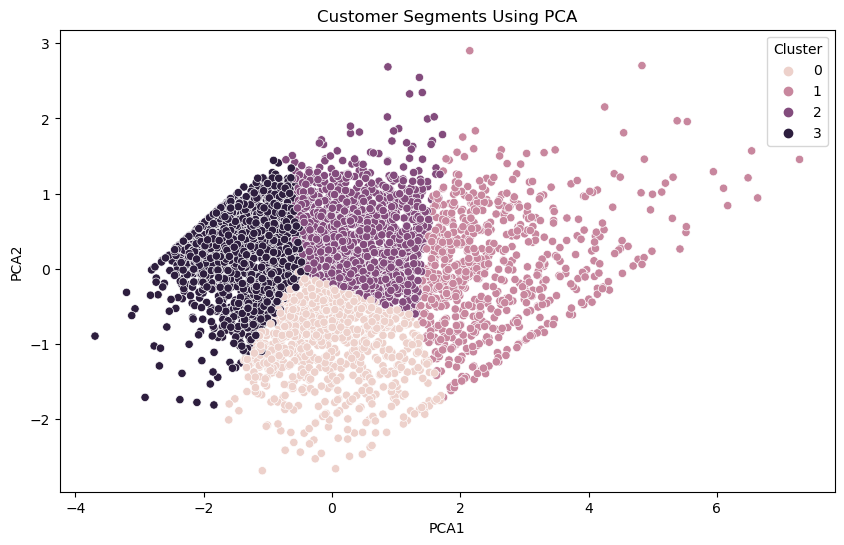

In [78]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster'
)

plt.title("Customer Segments Using PCA")
plt.show()

In [79]:
segment_map = {
    0: 'Active Customers',
    1: 'VIP Customers',
    2: 'Loyal Customers',
    3: 'At-Risk Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

In [80]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,2,Loyal Customers
12347.0,2,7,4310.00,1,VIP Customers
12348.0,75,4,1797.24,2,Loyal Customers
12349.0,19,1,1757.55,0,Active Customers
12350.0,310,1,334.40,3,At-Risk Customers


In [81]:
rfm['Segment'].value_counts()

At-Risk Customers    1612
Loyal Customers      1173
Active Customers      837
VIP Customers         716
Name: Segment, dtype: int64

In [83]:
rfm.to_csv('customer_segments.csv')

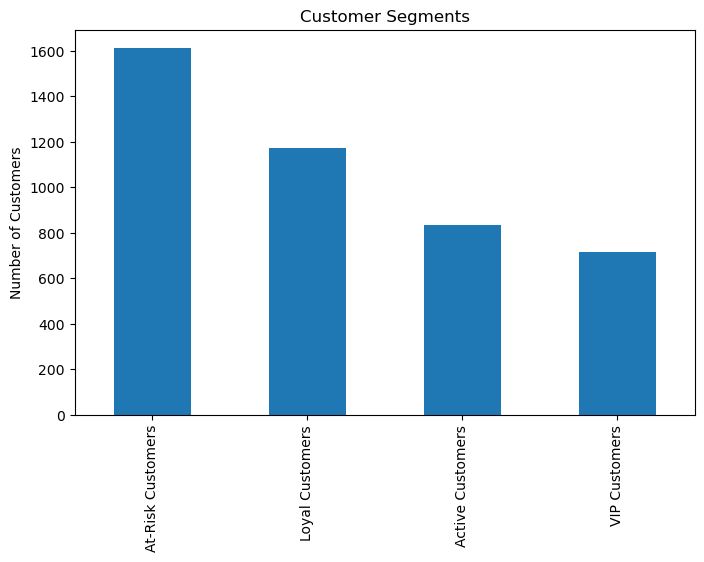

In [84]:
plt.figure(figsize=(8,5))

rfm['Segment'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Segments")
plt.ylabel("Number of Customers")
plt.show()

In [85]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()

segment_revenue.sort_values(
    ascending=False
)

Segment
VIP Customers        5781175.080
Loyal Customers      2114718.423
At-Risk Customers     553641.451
Active Customers      461872.950
Name: Monetary, dtype: float64

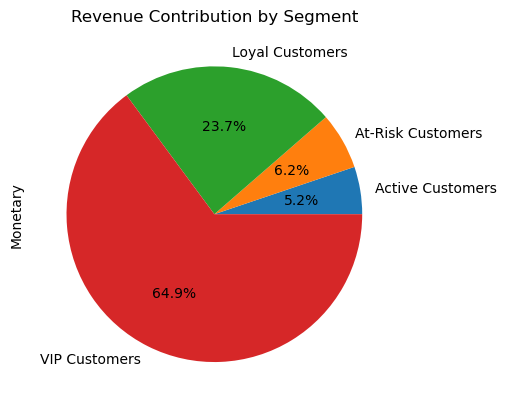

In [86]:
segment_revenue.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Revenue Contribution by Segment")
plt.show()

In [87]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
Active Customers,18.12,2.15,551.82
At-Risk Customers,182.50,1.32,343.45
Loyal Customers,71.08,4.08,1802.83
VIP Customers,12.13,13.71,8074.27


In [88]:
segment_summary.to_csv('segment_summary.csv')

In [89]:
rfm.sort_values(
    by='Monetary',
    ascending=False
).head(10)

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
14646.0,2,73,280206.02,1,VIP Customers
18102.0,1,60,259657.30,1,VIP Customers
17450.0,8,46,194550.79,1,VIP Customers
16446.0,1,2,168472.50,1,VIP Customers
14911.0,1,201,143825.06,1,VIP Customers
12415.0,24,21,124914.53,1,VIP Customers
14156.0,10,55,117379.63,1,VIP Customers
17511.0,3,31,91062.38,1,VIP Customers
16029.0,39,63,81024.84,1,VIP Customers


In [90]:
segment_revenue = rfm.groupby(
    'Segment'
)['Monetary'].sum()

segment_revenue

Segment
Active Customers      461872.950
At-Risk Customers     553641.451
Loyal Customers      2114718.423
VIP Customers        5781175.080
Name: Monetary, dtype: float64

In [91]:
pca_df.to_csv("pca_data.csv", index=False)

In [92]:
segment_map = {
    0: 'Active Customers',
    1: 'VIP Customers',
    2: 'Loyal Customers',
    3: 'At-Risk Customers'
}

pca_df['Segment'] = pca_df['Cluster'].map(segment_map)

pca_df.to_csv("pca_data.csv", index=False)